In [30]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

In [28]:
data = pd.read_csv('train.csv', header=None)
labels = pd.read_csv('trainLabels.csv', header=None)
train = pd.concat([data, labels], axis=1)
test = pd.read_csv("test.csv", header=None, skip_blank_lines=False)
X = train.iloc[:, :-1]
y = train.iloc[:, -1]
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

In [35]:
'''pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('mlp', MLPClassifier(max_iter=1500, random_state=42))
])
param_grid = {
    "mlp__hidden_layer_sizes": [(150,), (250,), (250,150), (150,75,50)],
    "mlp__activation": ["relu", "tanh"],
    "mlp__solver": ["adam", "sgd"],
    "mlp__alpha": [0.0001, 0.001, 0.01],   # régularisation L2
    "mlp__learning_rate_init": [0.001, 0.01]
}
grid = GridSearchCV(pipeline,
                    param_grid,
                    cv=5,
                    scoring="f1",
                    n_jobs=-1)
grid.fit(X, y)
print("best parameters", grid.best_params_)
print("Best_score F1: ", grid.best_score_)'''
param_dist = {
    "n_estimators": [500, 700, 1500],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

model = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_distributions=param_dist,
    n_iter=20,
    cv=5,
    scoring="f1",
    n_jobs=-1
)
model.fit(X, y)
best_model = model.best_estimator_

c:\Users\USER\AppData\Local\Programs\Python\Python314\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


In [38]:
print(model.best_score_)

0.873898648494204


In [36]:
#best_model = grid.best_estimator_
y_pred = best_model.predict(test)
submission = pd.DataFrame({
    "Id": range(1, len(y_pred)+1),
    "Solution": y_pred
})
print(submission.shape)   # doit donner (9000, 2)
submission.to_csv("submission.csv", index=False)


(9000, 2)


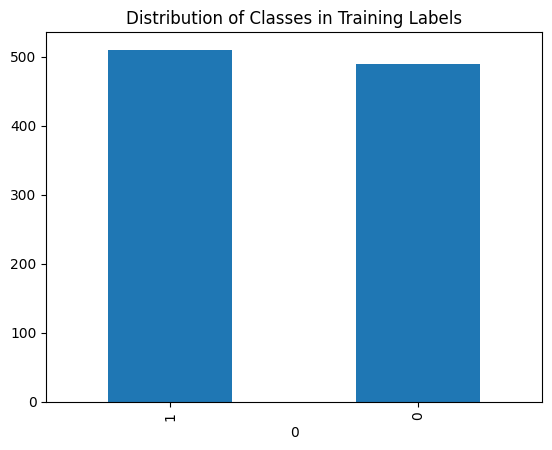

In [ ]:
import matplotlib.pyplot as plt
y.value_counts().plot(kind='bar')
plt.title('Distribution of Classes in Training Labels')
plt.show()

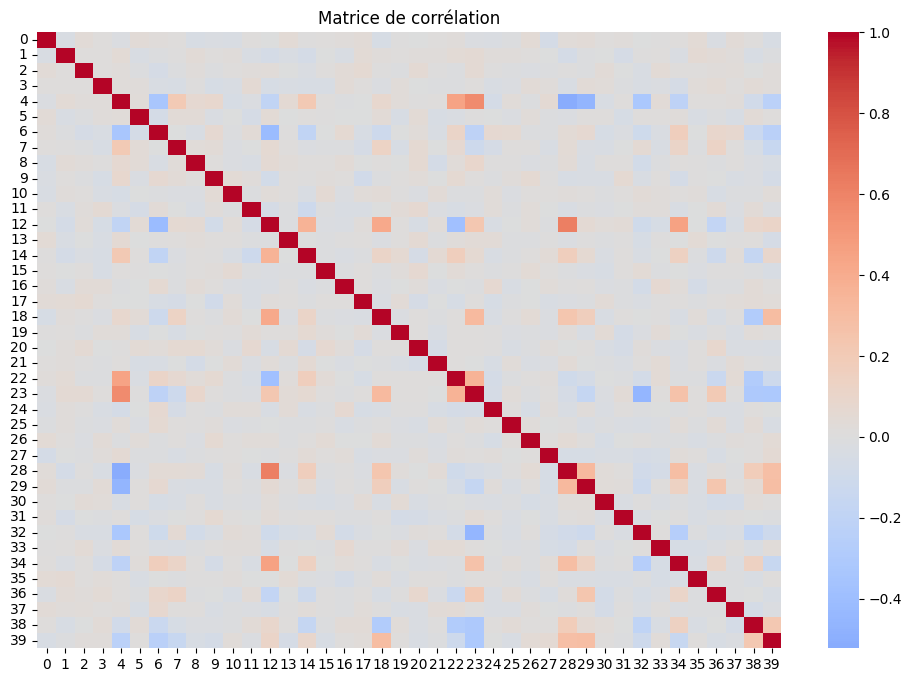

In [ ]:
import seaborn as sns

corr = train.iloc[:, :-1].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matrice de corrélation")
plt.show()


In [ ]:
import seaborn as sns

for i in range(10):  # les 5 premières features
    sns.boxplot(x=y, y=X.iloc[:, i])
    plt.title(f"Feature {i}")
    plt.show()
